# Optimization Note 3: Bound Constraints via the Logarithmic Barrier

**Goal:** Handle variable bounds $x \geq 0$ by converting a constrained problem into a sequence of unconstrained ones.

## The Constrained Problem

Most real problems have **bounds** on variables:

$$\min_x f(x) \quad \text{subject to} \quad x_i \geq \ell_i, \quad x_i \leq u_i$$

We can't just apply Newton/BFGS from Notes 1-2 — the iterates might violate the bounds.

## The Barrier Idea

Replace the hard constraint $x > 0$ with a **penalty** that goes to $+\infty$ as $x \to 0$:

$$\min_x \; f(x) - \mu \sum_i \ln(x_i - \ell_i) - \mu \sum_i \ln(u_i - x_i)$$

The parameter $\mu > 0$ controls the barrier strength:
- Large $\mu$: solution stays far from bounds (heavily penalized)
- Small $\mu$: solution approaches the true constrained optimum
- As $\mu \to 0$: barrier solution $\to$ constrained solution

This is the **central idea behind interior point methods**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=6, suppress=True)

## 1D Example: The Barrier in Action

Minimize $f(x) = (x - 3)^2$ subject to $x \geq 0$.

Unconstrained optimum: $x^* = 3$. Constrained optimum: $x^* = 3$ (bound not active).

Now change to $f(x) = (x + 1)^2$: unconstrained optimum $x^* = -1$, constrained optimum $x^* = 0$ (bound active).

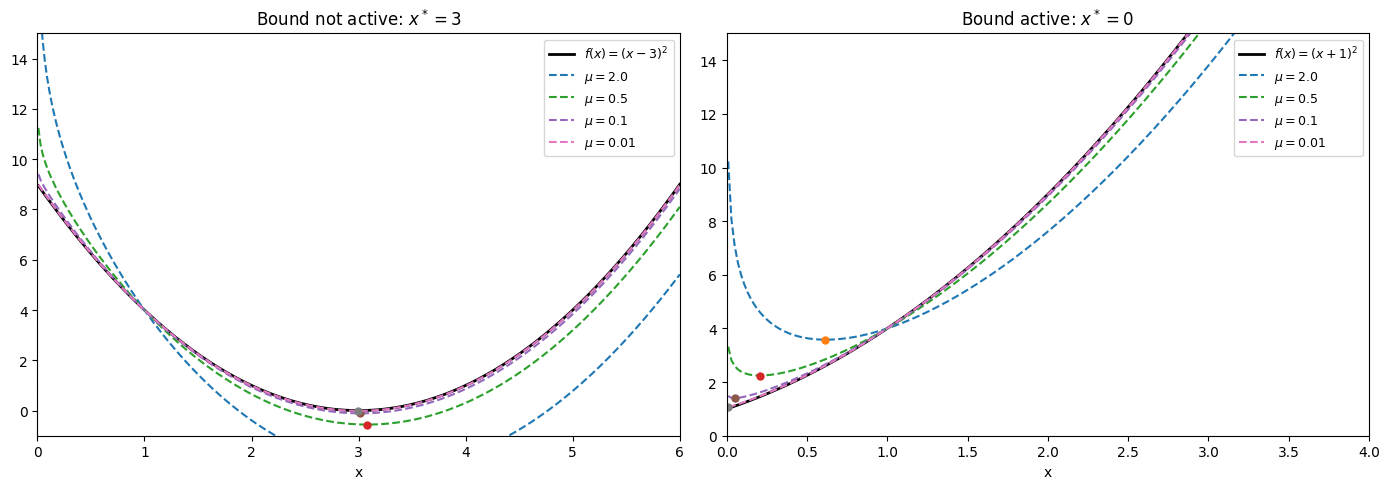

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Case 1: bound not active
x = np.linspace(0.01, 6, 300)
f1 = (x - 3)**2

axes[0].plot(x, f1, 'k-', linewidth=2, label='$f(x) = (x-3)^2$')
for mu in [2.0, 0.5, 0.1, 0.01]:
    barrier = f1 - mu * np.log(x)
    axes[0].plot(x, barrier, '--', label=f'$\\mu = {mu}$')
    # Find minimum
    x_min = x[np.argmin(barrier)]
    axes[0].plot(x_min, min(barrier), 'o', markersize=5)

axes[0].set_xlim(0, 6)
axes[0].set_ylim(-1, 15)
axes[0].set_title('Bound not active: $x^* = 3$')
axes[0].legend(fontsize=9)
axes[0].set_xlabel('x')
axes[0].axvline(x=0, color='gray', linestyle=':')

# Case 2: bound active
f2 = (x + 1)**2

axes[1].plot(x, f2, 'k-', linewidth=2, label='$f(x) = (x+1)^2$')
for mu in [2.0, 0.5, 0.1, 0.01]:
    barrier = f2 - mu * np.log(x)
    axes[1].plot(x, barrier, '--', label=f'$\\mu = {mu}$')
    x_min = x[np.argmin(barrier)]
    axes[1].plot(x_min, min(barrier), 'o', markersize=5)

axes[1].set_xlim(0, 4)
axes[1].set_ylim(0, 15)
axes[1].set_title('Bound active: $x^* = 0$')
axes[1].legend(fontsize=9)
axes[1].set_xlabel('x')
axes[1].axvline(x=0, color='gray', linestyle=':')

plt.tight_layout()
plt.show()

## The Central Path

As $\mu$ decreases, the barrier minimizers trace out a smooth curve called the **central path** that converges to the constrained optimum.

For the barrier problem with bounds $x \geq \ell$, the optimality condition is:

$$\nabla f(x) - \mu \sum_i \frac{e_i}{x_i - \ell_i} = 0$$

Define **multiplier estimates** $z_i = \frac{\mu}{x_i - \ell_i}$. Then:

$$\nabla f(x) = z, \quad z_i (x_i - \ell_i) = \mu$$

The second equation is the **complementarity condition**. As $\mu \to 0$: either $z_i \to 0$ (bound inactive) or $x_i \to \ell_i$ (bound active). This is exactly the KKT conditions!

In [3]:
def barrier_solver(f, grad, hess, x0, lower_bounds, upper_bounds,
                   mu_init=1.0, mu_factor=0.2, mu_min=1e-10,
                   tol=1e-8, max_outer=50, max_inner=50):
    """Simple barrier method for bound-constrained optimization.
    
    Solves: min f(x) s.t. lower <= x <= upper
    by solving a sequence of unconstrained barrier subproblems.
    """
    n = len(x0)
    x = np.array(x0, dtype=float)
    mu = mu_init
    lb = np.array(lower_bounds, dtype=float)
    ub = np.array(upper_bounds, dtype=float)
    
    history = []
    
    for outer in range(max_outer):
        # Define barrier objective
        def barrier_f(x):
            val = f(x)
            for i in range(n):
                if np.isfinite(lb[i]):
                    if x[i] <= lb[i]: return 1e20
                    val -= mu * np.log(x[i] - lb[i])
                if np.isfinite(ub[i]):
                    if x[i] >= ub[i]: return 1e20
                    val -= mu * np.log(ub[i] - x[i])
            return val
        
        def barrier_grad(x):
            g = grad(x).copy()
            for i in range(n):
                if np.isfinite(lb[i]):
                    g[i] -= mu / (x[i] - lb[i])
                if np.isfinite(ub[i]):
                    g[i] += mu / (ub[i] - x[i])
            return g
        
        def barrier_hess(x):
            H = hess(x).copy()
            for i in range(n):
                if np.isfinite(lb[i]):
                    H[i, i] += mu / (x[i] - lb[i])**2
                if np.isfinite(ub[i]):
                    H[i, i] += mu / (ub[i] - x[i])**2
            return H
        
        # Solve barrier subproblem with damped Newton
        for inner in range(max_inner):
            g = barrier_grad(x)
            if np.linalg.norm(g) < max(tol, 0.1 * mu):
                break
            
            H = barrier_hess(x)
            d = np.linalg.solve(H, -g)
            
            # Fraction-to-boundary: ensure x + alpha*d stays feasible
            alpha = 1.0
            tau = 0.995
            for i in range(n):
                if d[i] < 0 and np.isfinite(lb[i]):
                    alpha = min(alpha, -tau * (x[i] - lb[i]) / d[i])
                if d[i] > 0 and np.isfinite(ub[i]):
                    alpha = min(alpha, tau * (ub[i] - x[i]) / d[i])
            
            # Backtracking on barrier objective
            f0 = barrier_f(x)
            slope = g @ d
            for _ in range(20):
                if barrier_f(x + alpha * d) <= f0 + 1e-4 * alpha * slope:
                    break
                alpha *= 0.5
            
            x = x + alpha * d
        
        # Compute bound multiplier estimates
        z_lower = np.zeros(n)
        z_upper = np.zeros(n)
        for i in range(n):
            if np.isfinite(lb[i]):
                z_lower[i] = mu / (x[i] - lb[i])
            if np.isfinite(ub[i]):
                z_upper[i] = mu / (ub[i] - x[i])
        
        # Complementarity error
        compl = max(
            max((z_lower[i] * (x[i] - lb[i]) for i in range(n) if np.isfinite(lb[i])), default=0),
            max((z_upper[i] * (ub[i] - x[i]) for i in range(n) if np.isfinite(ub[i])), default=0)
        )
        
        history.append({
            'mu': mu, 'x': x.copy(), 'f': f(x),
            'grad_norm': np.linalg.norm(grad(x) - z_lower + z_upper),
            'compl': compl
        })
        
        if mu < mu_min:
            break
        
        mu *= mu_factor
    
    return x, history

In [4]:
# Example: minimize (x-3)^2 + (y+1)^2 subject to x >= 0, y >= 0
f = lambda x: (x[0] - 3)**2 + (x[1] + 1)**2
grad_f = lambda x: np.array([2*(x[0] - 3), 2*(x[1] + 1)])
hess_f = lambda x: np.array([[2.0, 0.0], [0.0, 2.0]])

x0 = np.array([1.0, 1.0])
lb = [0.0, 0.0]
ub = [np.inf, np.inf]

x_opt, hist = barrier_solver(f, grad_f, hess_f, x0, lb, ub)

print(f"Solution: x = {x_opt}")
print(f"Expected: x = [3, 0]  (y-bound is active)")
print(f"f(x*) = {f(x_opt):.6f}")
print()
print(f"{'Outer':>5} {'mu':>10} {'f(x)':>10} {'||KKT||':>10} {'compl':>10} {'x':>20}")
print("-" * 70)
for i, h in enumerate(hist):
    print(f"{i:>5} {h['mu']:>10.2e} {h['f']:>10.4f} {h['grad_norm']:>10.2e} {h['compl']:>10.2e} {str(h['x']):>20}")

Solution: x = [3. 0.]
Expected: x = [3, 0]  (y-bound is active)
f(x*) = 1.000000

Outer         mu       f(x)    ||KKT||      compl                    x
----------------------------------------------------------------------
    0   1.00e+00     1.8764   5.14e-02   1.00e+00  [3.158312 0.360657]
    1   2.00e-01     1.1927   4.93e-04   2.00e-01  [3.032971 0.091589]
    2   4.00e-02     1.0396   1.99e-03   4.00e-02  [3.006652 0.019596]
    3   8.00e-03     1.0080   2.29e-05   8.00e-03  [3.001333 0.003984]
    4   1.60e-03     1.0016   3.97e-05   1.60e-03  [3.000267 0.000799]
    5   3.20e-04     1.0003   9.65e-10   3.20e-04  [3.000053 0.00016 ]
    6   6.40e-05     1.0001   1.01e-09   6.40e-05  [3.000011 0.000032]
    7   1.28e-05     1.0000   1.02e-09   1.28e-05  [3.000002 0.000006]
    8   2.56e-06     1.0000   1.02e-09   2.56e-06  [3.       0.000001]
    9   5.12e-07     1.0000   1.02e-09   5.12e-07              [3. 0.]
   10   1.02e-07     1.0000   1.02e-09   1.02e-07              [3.

## The Barrier Hessian

The Hessian of the barrier subproblem is:

$$\nabla^2 \varphi_\mu(x) = \nabla^2 f(x) + \Sigma$$

where $\Sigma$ is the **barrier diagonal**:

$$\Sigma_{ii} = \frac{\mu}{(x_i - \ell_i)^2} + \frac{\mu}{(u_i - x_i)^2}$$

Near a bound, $\Sigma_{ii} \to \infty$, which:
1. Makes the Hessian very well-conditioned along the bound directions
2. Automatically **stiffens** the system to prevent bound violation
3. Connects to the linear solver work: $\Sigma$ appears as a diagonal addition in the KKT matrix

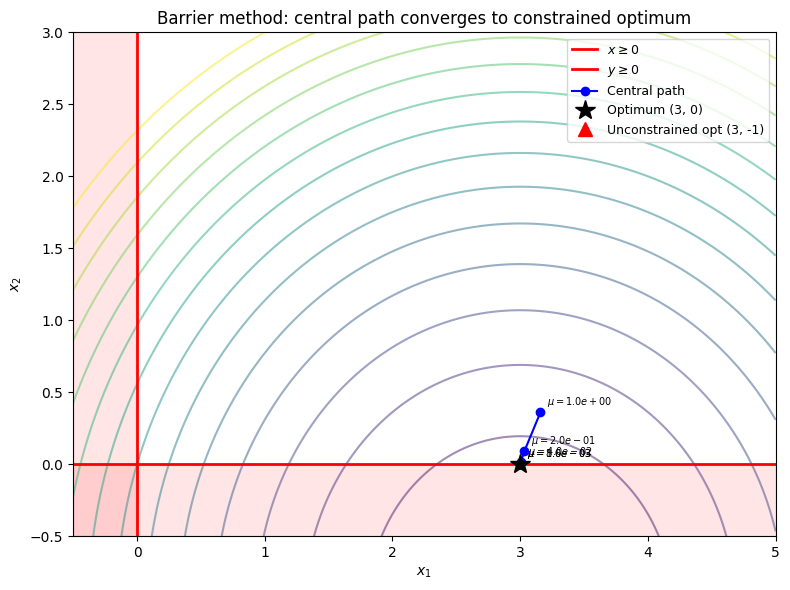

In [5]:
# Visualize the central path
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Contours of f
xx = np.linspace(-0.5, 5, 200)
yy = np.linspace(-0.5, 3, 200)
X, Y = np.meshgrid(xx, yy)
Z = (X - 3)**2 + (Y + 1)**2
ax.contour(X, Y, Z, levels=np.linspace(0, 20, 15), cmap='viridis', alpha=0.5)

# Feasible region
ax.axvline(x=0, color='red', linewidth=2, label='$x \\geq 0$')
ax.axhline(y=0, color='red', linewidth=2, label='$y \\geq 0$')
ax.fill_between([-0.5, 0], -0.5, 3, alpha=0.1, color='red')
ax.fill_betweenx([-0.5, 0], -0.5, 5, alpha=0.1, color='red')

# Central path
path = np.array([h['x'] for h in hist])
ax.plot(path[:, 0], path[:, 1], 'bo-', markersize=6, label='Central path')
ax.plot(3, 0, 'k*', markersize=15, label='Optimum (3, 0)')
ax.plot(3, -1, 'r^', markersize=10, label='Unconstrained opt (3, -1)')

for i, h in enumerate(hist[:5]):
    ax.annotate(f'$\\mu={h["mu"]:.1e}$', xy=h['x'], fontsize=7,
                xytext=(5, 5), textcoords='offset points')

ax.set_xlim(-0.5, 5)
ax.set_ylim(-0.5, 3)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Barrier method: central path converges to constrained optimum')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## The Fraction-to-Boundary Rule

A key practical detail: we must ensure iterates stay **strictly inside** the feasible region. The **fraction-to-boundary rule** limits the step length:

$$\alpha_{\max} = \max\{\alpha \in (0, 1] : x + \alpha d \geq \ell + (1-\tau)(x - \ell)\}$$

which simplifies to checking each component:

$$\alpha_{\max} = \min_i \left\{ -\frac{\tau (x_i - \ell_i)}{d_i} : d_i < 0 \right\}$$

with $\tau \in (0, 1)$ (ripopt uses $\tau_{\min} = 0.99$). This is cheap: $O(n)$ per step.

## Limitations of the Simple Barrier Approach

Our barrier solver works but has issues:

1. **Nested loops:** Each outer iteration requires fully solving an inner unconstrained problem
2. **Ill-conditioning:** As $\mu \to 0$, the barrier Hessian becomes very ill-conditioned
3. **No constraints beyond bounds:** Can't handle $g(x) = 0$ or $g(x) \leq 0$

The **primal-dual interior point method** (Note 4) fixes all of these by solving the KKT system directly, treating $\mu$ as a parameter that decreases adaptively.

In [6]:
# A harder example: bound-constrained Rosenbrock
# min rosenbrock(x) s.t. 0 <= x_i <= 0.5
# True constrained optimum: x = [0.5, 0.25]

def rosenbrock(x):
    return 100 * (x[1] - x[0]**2)**2 + (1 - x[0])**2

def rosenbrock_grad(x):
    return np.array([
        -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0]),
        200 * (x[1] - x[0]**2)
    ])

def rosenbrock_hess(x):
    return np.array([
        [1200 * x[0]**2 - 400 * x[1] + 2, -400 * x[0]],
        [-400 * x[0], 200]
    ])

x0 = np.array([0.25, 0.25])
lb = [0.0, 0.0]
ub = [0.5, 0.5]

x_opt, hist = barrier_solver(rosenbrock, rosenbrock_grad, rosenbrock_hess, x0, lb, ub,
                             mu_init=0.1)

print(f"Solution: x = {x_opt}")
print(f"f(x*) = {rosenbrock(x_opt):.6f}")
print(f"Expected: x ≈ [0.5, 0.25], f ≈ 0.25")
print(f"\nActive bounds: x[0] = {x_opt[0]:.6f} (upper bound 0.5)")

Solution: x = [0.5  0.25]
f(x*) = 0.250000
Expected: x ≈ [0.5, 0.25], f ≈ 0.25

Active bounds: x[0] = 0.500000 (upper bound 0.5)


## What We've Learned

1. The **log barrier** converts bounds into a smooth penalty: $-\mu \ln(x - \ell)$
2. Decreasing $\mu$ traces the **central path** from interior to constrained optimum
3. The barrier generates **bound multiplier estimates** $z = \mu / (x - \ell)$
4. The **fraction-to-boundary rule** keeps iterates strictly feasible
5. As $\mu \to 0$, the KKT conditions are satisfied: complementarity $z(x-\ell) = \mu \to 0$

## What's Next

In Note 4, we reformulate the barrier approach as a **primal-dual interior point method** that solves a single KKT system per iteration (no nested loops), handles the barrier parameter adaptively, and naturally extends to equality and inequality constraints.

---

*This is Optimization Note 3 in a series building from Newton's method to the interior point optimizer [ripopt](https://github.com/jkitchin/ripopt).*